In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "medical_cost_personal_dataset" / "insurance.csv"
df = pd.read_csv(train_path)

In [3]:
X = df.drop(columns="charges")
y = df["charges"]
num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)

predictions = {}

In [4]:
for name, estimator in {
    "ordinary least squares": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
}.items():
    model = Pipeline([("preprocess", preprocess), ("model", estimator)])
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    predictions[name] = pred
    print("\n", name)
    print("MAE:", round(mean_absolute_error(y_valid, pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_valid, pred)), 2))
    print("R2:", round(r2_score(y_valid, pred), 3))


 ordinary least squares
MAE: 4181.19
RMSE: 5796.28
R2: 0.784

 ridge
MAE: 4238.82
RMSE: 5821.59
R2: 0.782


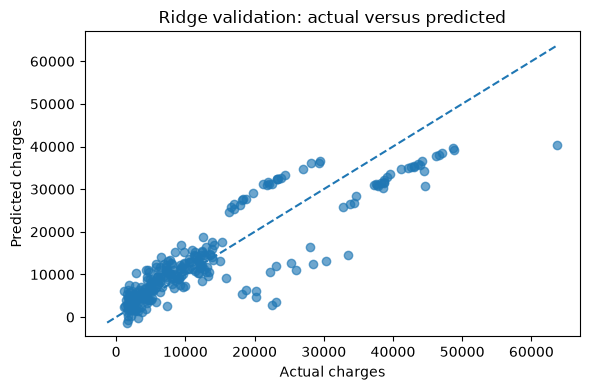

In [5]:
# Visual diagnostics for the regularized model.
ridge_pred = predictions["ridge"]
plt.figure(figsize=(6, 4))
plt.scatter(y_valid, ridge_pred, alpha=0.65)
lims = [min(y_valid.min(), ridge_pred.min()), max(y_valid.max(), ridge_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Ridge validation: actual versus predicted")
plt.tight_layout()
plt.show()

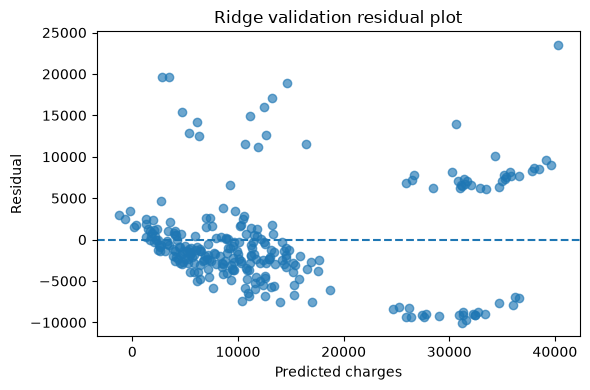

In [6]:
residual = y_valid.to_numpy() - ridge_pred
plt.figure(figsize=(6, 4))
plt.scatter(ridge_pred, residual, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted charges")
plt.ylabel("Residual")
plt.title("Ridge validation residual plot")
plt.tight_layout()
plt.show()